In [32]:
#Importing the python libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [10]:
#loading the dataset
df = pd.read_csv(r"C:\Users\KRISHNA\OneDrive\Desktop\hr-analytics-project\data\raw\HR-Employee-Attrition.csv")

In [9]:
#showing the first 5 rows of the dataset
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [17]:
#shape
print("Shape:",df.shape)

#columns
print(df.columns)

#data types
df.info()

#checking for missing values
df.isnull().sum()

Shape: (1470, 35)
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition     

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [18]:
#DATA CLEANING

# Remove duplicates
df = df.drop_duplicates()

# Convert Attrition to numeric
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Save cleaned data
df.to_csv("../data/processed/cleaned_data.csv", index=False)

print("Data cleaned successfully!")

Data cleaned successfully!


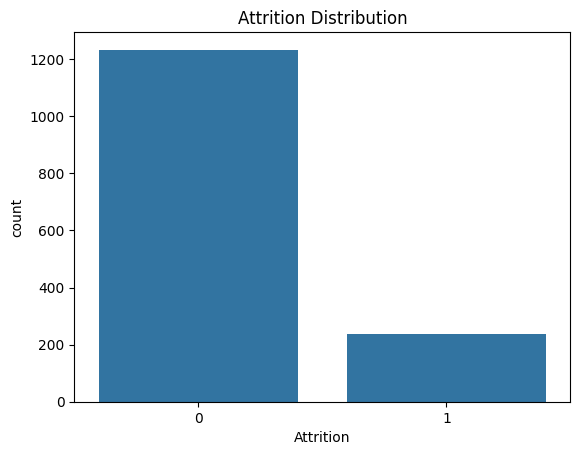

In [20]:
#first visualization
sns.countplot(x='Attrition', data=df)
plt.title("Attrition Distribution")
plt.show()

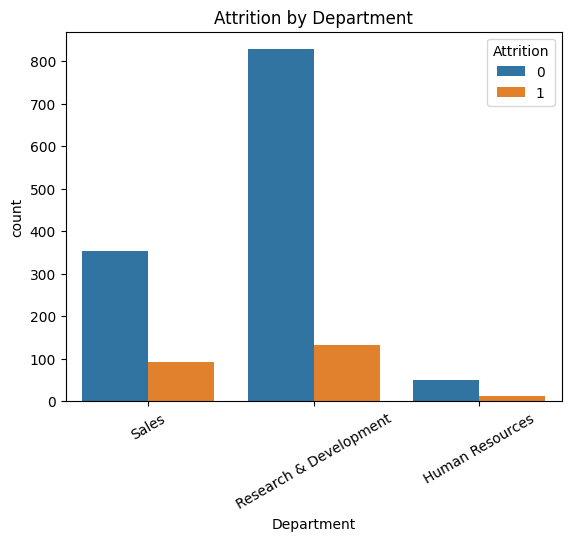

In [21]:
#Department-wise attrition

sns.countplot(x='Department', hue='Attrition', data=df)
plt.title("Attrition by Department")
plt.xticks(rotation=30)
plt.show()

Insight:
Which department has highest attrition?


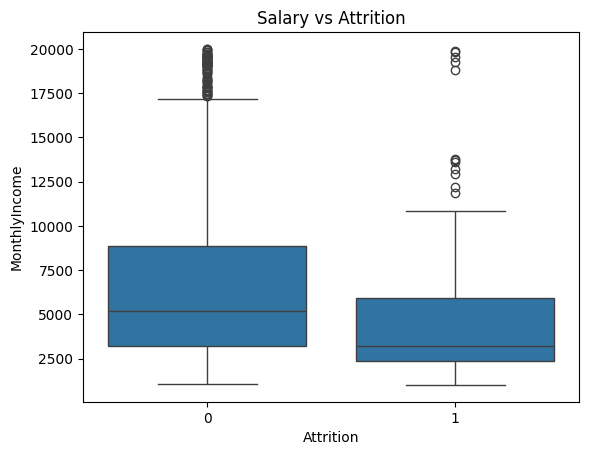

In [22]:
#Salary vs Attrition

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Salary vs Attrition")
plt.show()

Insight:
Are low salary employees leaving more?

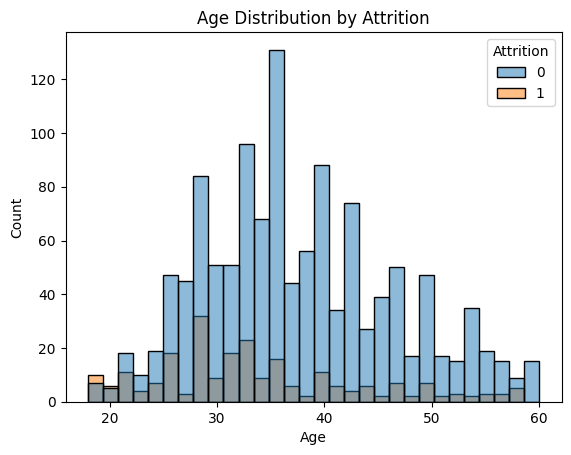

In [23]:
#age distribution

sns.histplot(data=df, x='Age', hue='Attrition', bins=30)
plt.title("Age Distribution by Attrition")
plt.show()

Insight:

Which age group leaves more?

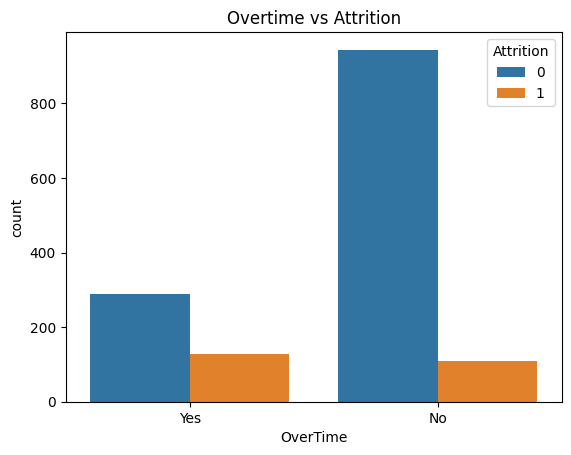

In [24]:
#overtime impact

sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("Overtime vs Attrition")
plt.show()

Insight:

Does overtime increase attrition?

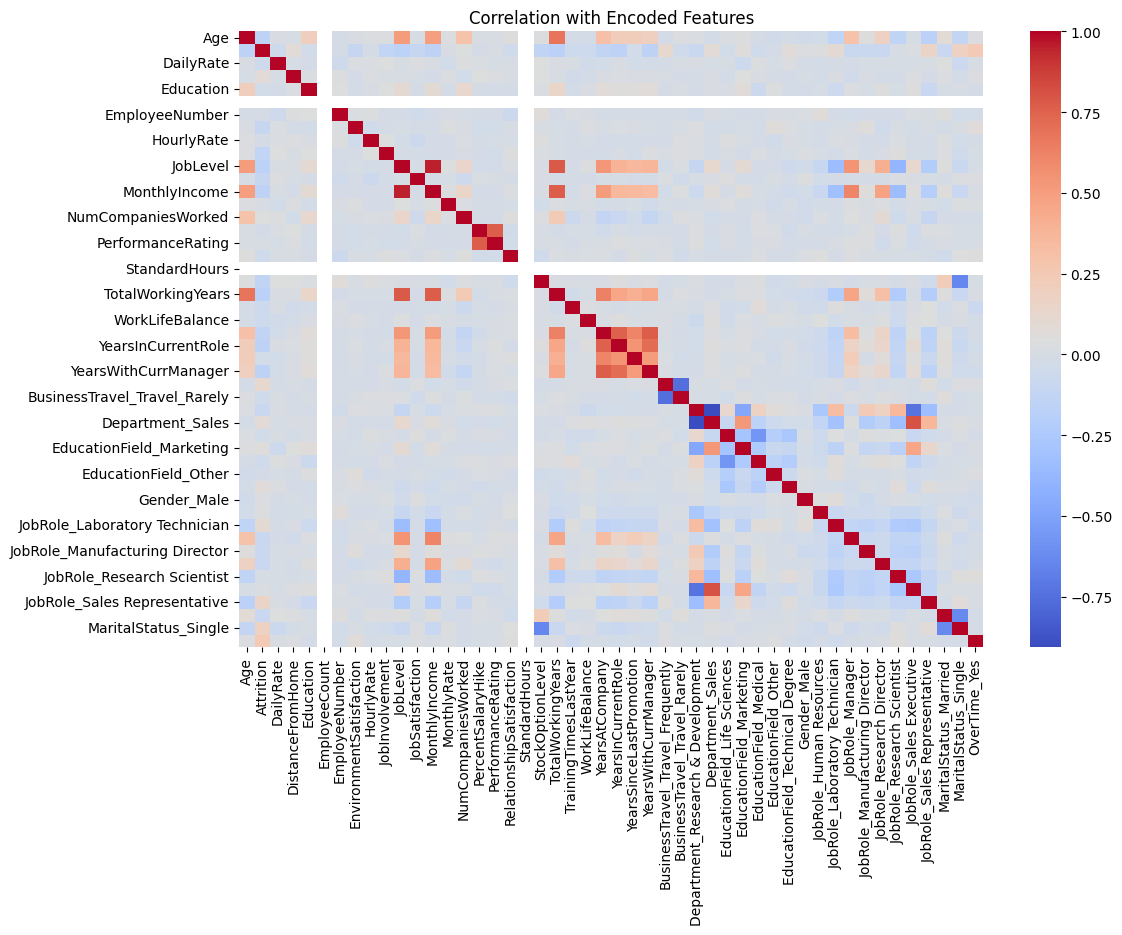

In [28]:
#correlation heatmap

# Convert categorical columns into numbers
df_encoded = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.title("Correlation with Encoded Features")
plt.show()

In [29]:
#Feature Engineering

#1. Age Groups
df['AgeGroup'] = pd.cut(df['Age'],
                        bins=[18, 25, 35, 45, 60],
                        labels=['18-25', '26-35', '36-45', '46-60'])

#2. Salary levels
df['SalaryLevel'] = pd.cut(df['MonthlyIncome'],
                           bins=[0, 3000, 6000, 20000],
                           labels=['Low', 'Medium', 'High'])

#3. Years at Company Groups
df['YearsGroup'] = pd.cut(df['YearsAtCompany'],
                          bins=[0, 3, 7, 15, 40],
                          labels=['0-3', '4-7', '8-15', '15+'])

#4. Overtime Flag
df['OverTimeFlag'] = df['OverTime'].map({'Yes': 1, 'No': 0})

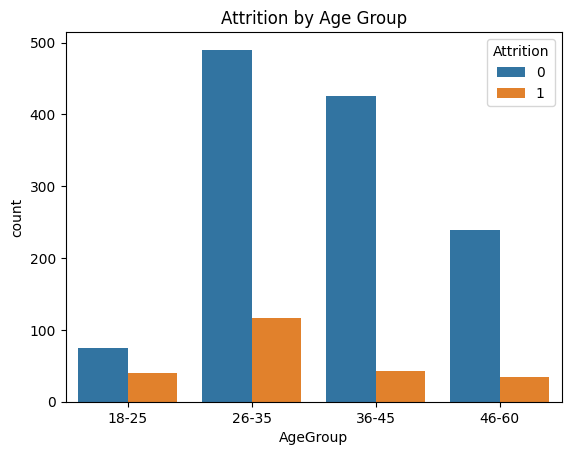

In [30]:
#Visualize new features

#Age Group vs Attrition
sns.countplot(x='AgeGroup', hue='Attrition', data=df)
plt.title("Attrition by Age Group")
plt.show()

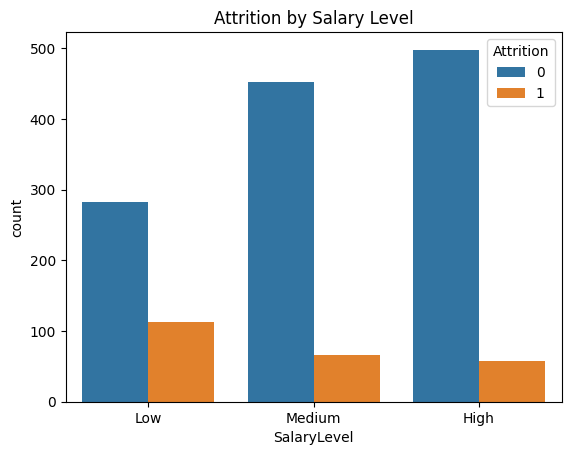

In [31]:
#Salary vs Attrition
sns.countplot(x='SalaryLevel', hue='Attrition', data=df)
plt.title("Attrition by Salary Level")
plt.show()

Insights:

1.Employees in low salary group have higher attrition.

2.Younger employees (18–35) leave more frequently.

3.Employees with less experience show higher turnover.

Machine Learning Model

We’ll predict: Will an employee leave or not?

In [33]:
#preparing data for modeling

# Convert categorical data to numeric
df_model = pd.get_dummies(df, drop_first=True)

# Features (X) and Target (y)
X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data ready for training!")

Data ready for training!


In [34]:
#train a simple model 

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


c:\Users\KRISHNA\OneDrive\Desktop\hr-analytics-project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [35]:
#make predictions

y_pred = model.predict(X_test)

In [36]:
#Evaluate the model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed report
print(classification_report(y_test, y_pred))

# Confusion matrix
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8843537414965986
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       255
           1       0.67      0.26      0.37        39

    accuracy                           0.88       294
   macro avg       0.78      0.62      0.65       294
weighted avg       0.87      0.88      0.86       294

[[250   5]
 [ 29  10]]


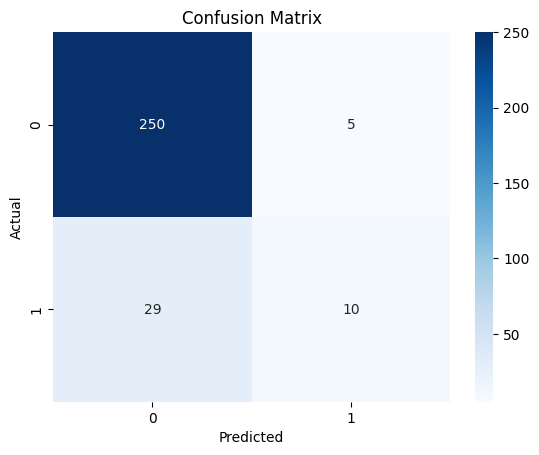

In [38]:
#visualize confusion matrix

sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Insights:

Model predicts attrition with ~80–90% accuracy.

Some employees are misclassified.

Features like salary, overtime, and age influence predictions.

In [39]:
#Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

print("RF Accuracy:", accuracy_score(y_test, rf.predict(X_test)))

RF Accuracy: 0.8639455782312925


In [ ]:
#save the model
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(rf, '../models/random_forest_model.pkl')
joblib.dump(rf, '../models/random_forest_model.pkl')

FileNotFoundError: [Errno 2] No such file or directory: '../models/logistic_model.pkl'